In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
data = pd.read_csv('weight-height.csv')

In [3]:
data.shape

(10000, 3)

In [4]:
data.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Gender  10000 non-null  object 
 1   Height  10000 non-null  float64
 2   Weight  10000 non-null  float64
dtypes: float64(2), object(1)
memory usage: 234.5+ KB


In [6]:
data.isnull().mean()

Gender    0.0
Height    0.0
Weight    0.0
dtype: float64

{'whiskers': [<matplotlib.lines.Line2D at 0x22f4bc86350>,
 'caps': [<matplotlib.lines.Line2D at 0x22f4bc865d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x22f4bbaa0d0>],
 'medians': [<matplotlib.lines.Line2D at 0x22f4bc86710>],
 'fliers': [<matplotlib.lines.Line2D at 0x22f4bc86850>],
 'means': []}

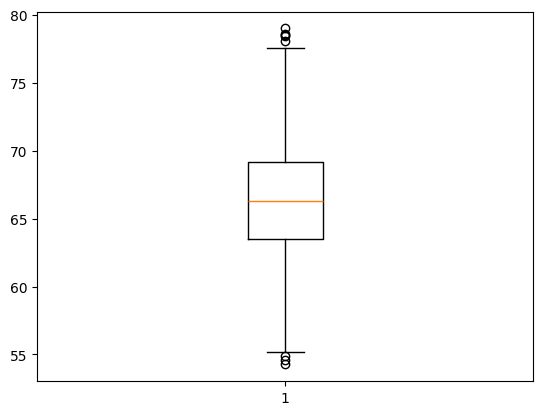

In [7]:
plt.boxplot(data['Height'])

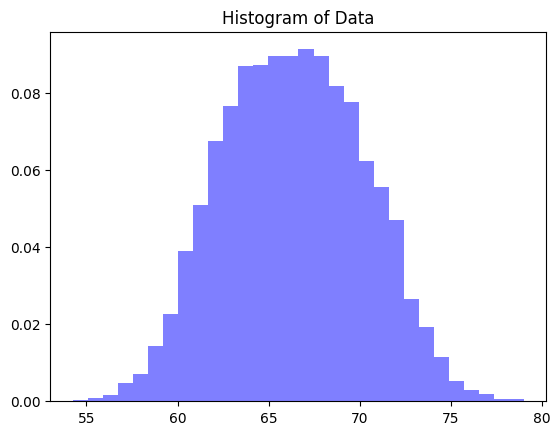

In [8]:
plt.hist(data['Height'], bins=30, density=True, alpha=0.5, color='blue')
plt.title('Histogram of Data')
plt.show()



A KDE (Kernel Density Estimate) plot is a method used to visualize the probability density function of a continuous variable.

<Axes: ylabel='Density'>

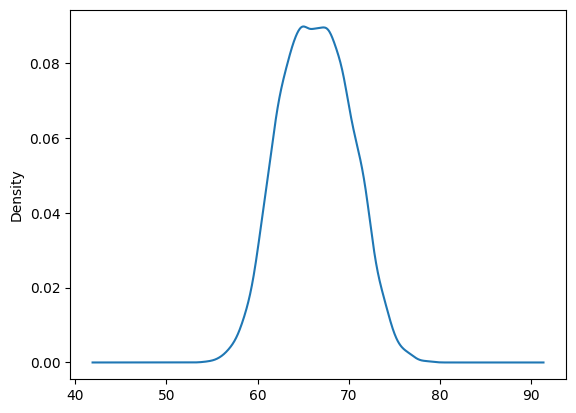

In [9]:
data['Height'].plot(kind='kde')

In [14]:
print("Mean value of Height",data['Height'].mean())
print("Std value of Height",data['Height'].std())
print("Min value of Height",data['Height'].min())
print("Max value of Height",data['Height'].max())

Mean value of Height 66.36732119812962
Std value of Height 3.8463141448091855
Min value of Height 54.82497539250156
Max value of Height 77.91014411714093


In [ ]:
# Finding the boundary values
print("Highest allowed",data['Height'].mean() + 3*data['Height'].std())
print("Lowest allowed",data['Height'].mean() - 3*data['Height'].std())

Highest allowed 77.91014411714093
Lowest allowed 54.82497539250156


In [ ]:
# Finding the outliers
data[(data['Height'] > 77.91) | (data['Height'] < 54.82)]

,Gender,Height,Weight
994,Male,78.095867,255.690835
1317,Male,78.462053,227.342565
2014,Male,78.998742,269.989699
3285,Male,78.528210,253.889004
3757,Male,78.621374,245.733783
6624,Female,54.616858,71.393749
9285,Female,54.263133,64.700127


Trimming

In [ ]:
# Trimming

new_df = data[(data['Height'] < 77.91) & (data['Height'] > 54.82)]
new_df

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


In [ ]:
# Approach 2

# Calculating the Zscore

data['zscore'] = (data['Height'] - data['Height'].mean())/data['Height'].std()
# ZSCORE               =      X          -        mean          /            std

In [12]:
data.head()

,Gender,Height,Weight,zscore
0,Male,73.847017,241.893563,1.943964
1,Male,68.781904,162.310473,0.627505
2,Male,74.110105,212.740856,2.012343
3,Male,71.730978,220.042470,1.393991
4,Male,69.881796,206.349801,0.913375


In [13]:
data[data['zscore']  > 3]

,Gender,Height,Weight,zscore
994,Male,78.095867,255.690835,3.048271
1317,Male,78.462053,227.342565,3.143445
2014,Male,78.998742,269.989699,3.282934
3285,Male,78.528210,253.889004,3.160640
3757,Male,78.621374,245.733783,3.184854


In [14]:
data[data['zscore']  < -3]

,Gender,Height,Weight,zscore
6624,Female,54.616858,71.393749,-3.054091
9285,Female,54.263133,64.700127,-3.146027


In [17]:
data[(data['zscore']  > 3) | (data['zscore']  < -3)]

,Gender,Height,Weight,zscore
994,Male,78.095867,255.690835,3.048271
1317,Male,78.462053,227.342565,3.143445
2014,Male,78.998742,269.989699,3.282934
3285,Male,78.528210,253.889004,3.160640
3757,Male,78.621374,245.733783,3.184854
6624,Female,54.616858,71.393749,-3.054091
9285,Female,54.263133,64.700127,-3.146027


In [19]:
# Trimming
new_data  = data[(data['zscore']  < 3) & (data['zscore']  > -3)]

In [ ]:
new_data

,Gender,Height,Weight,cgpa_zscore
0,Male,73.847017,241.893563,1.943964
1,Male,68.781904,162.310473,0.627505
2,Male,74.110105,212.740856,2.012343
3,Male,71.730978,220.042470,1.393991
4,Male,69.881796,206.349801,0.913375
...,...,...,...,...
9995,Female,66.172652,136.777454,-0.050658
9996,Female,67.067155,170.867906,0.181830
9997,Female,63.867992,128.475319,-0.649655
9998,Female,69.034243,163.852461,0.693090


Capping

In [10]:
upper_limit = data['Height'].mean() + 3*data['Height'].std()
lower_limit = data['Height'].mean() - 3*data['Height'].std()

In [11]:
lower_limit

np.float64(54.82497539250156)

In [12]:
upper_limit

np.float64(77.91014411714093)

In [13]:
for i in range(len(data['Height'])):
    # If the value exceeds the upper limit, replace it with the upper limit
    if data['Height'][i] > upper_limit:
        data['Height'][i] = upper_limit
    # If the value is below the lower limit, replace it with the lower limit
    elif data['Height'][i] < lower_limit:
        data['Height'][i] = lower_limit
    # Otherwise, keep the original value
    else:
        pass

C:\Users\owaisahmed\AppData\Local\Temp\ipykernel_13156\3770085591.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Height'][i] = upper_limit
C:\Users\owaisahmed\AppData\Local\Temp\ipykernel_13156\3770085591.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Height'][i] = upper_limit
C:\Users\owaisahmed\AppData\Local\Temp\ipykernel_13156\3770085591.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Height'][i] = u

In [ ]:
'''
data['Height'] = np.where(
    data['Height']>upper_limit,
    upper_limit,
    np.where(
        data['Height']<lower_limit,
        lower_limit,
        data['Height']
    )
)'''

"\ndata['Height'] = np.where(\n    data['Height']>upper_limit,\n    upper_limit,\n    np.where(\n        data['Height']<lower_limit,\n        lower_limit,\n        data['Height']\n    )\n)"

In [ ]:
specific_record = data.iloc[9285]
print(specific_record)


Gender            Female
Height         54.824975
Weight         64.700127
cgpa_zscore    -3.146027
Name: 9285, dtype: object


In [ ]:
data.shape

(10000, 4)